In [1]:
print("Mi primer proyecto de Data Science")

Mi primer proyecto de Data Science


In [2]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "openpyxl"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv(r"C:\Users\chris\credit-churn-analysis\BankChurners.csv")

# Ver las primeras filas
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
# ¿Cuántos clientes y columnas tenemos?
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

# ¿Cuántos se dieron de baja vs siguen activos?
print("\nDistribución de clientes:")
print(df['Attrition_Flag'].value_counts())
print(df['Attrition_Flag'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Filas: 10,127
Columnas: 23

Distribución de clientes:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    83.9%
Attrited Customer    16.1%
Name: proportion, dtype: str


In [5]:
# ¿Hay datos nulos?
print("=== VALORES NULOS ===")
print(df.isnull().sum())

# ¿Qué tipo de datos tenemos?
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

=== VALORES NULOS ===
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category           

In [6]:
# Eliminar columnas que no necesitamos
df = df.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

# Convertir variable objetivo a numérico
df['Churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)
df = df.drop(columns=['Attrition_Flag'])

print(f"Columnas finales: {df.shape[1]}")
print(f"\nDistribución Churn:")
print(df['Churn'].value_counts())

Columnas finales: 20

Distribución Churn:
Churn
0    8500
1    1627
Name: count, dtype: int64


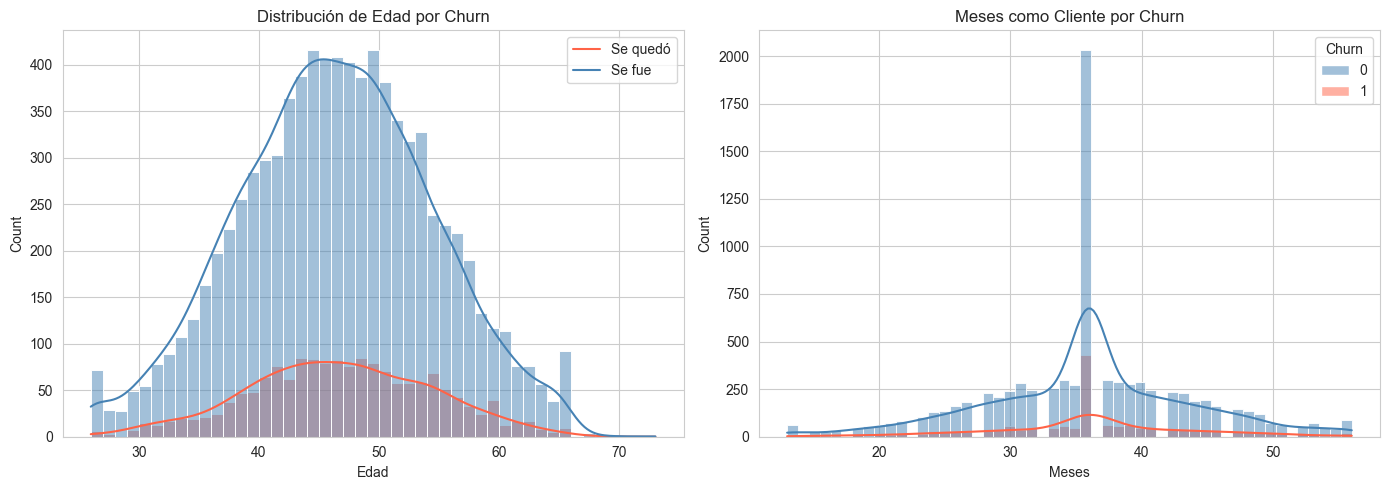

In [7]:
# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Comparar edad y meses como cliente entre quienes se van vs se quedan
fig, axes = plt.subplots(1, 2)

sns.histplot(data=df, x='Customer_Age', hue='Churn', kde=True, ax=axes[0], palette={0:'steelblue', 1:'tomato'})
axes[0].set_title('Distribución de Edad por Churn')
axes[0].set_xlabel('Edad')
axes[0].legend(['Se quedó', 'Se fue'])

sns.histplot(data=df, x='Months_on_book', hue='Churn', kde=True, ax=axes[1], palette={0:'steelblue', 1:'tomato'})
axes[1].set_title('Meses como Cliente por Churn')
axes[1].set_xlabel('Meses')

plt.tight_layout()
plt.show()

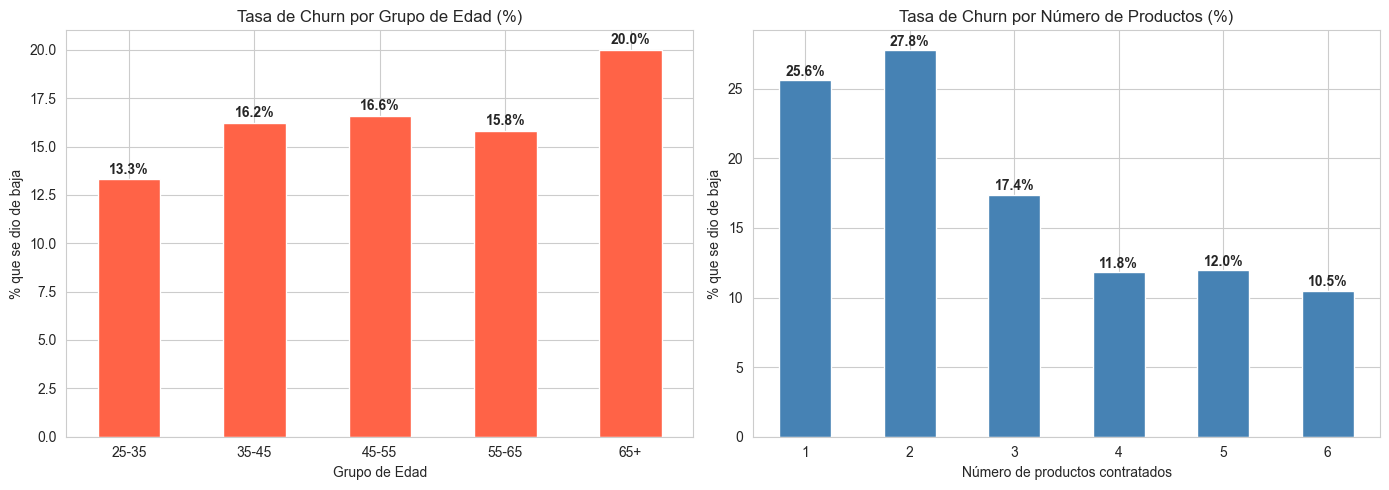

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por grupo de edad
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=[25, 35, 45, 55, 65, 75], 
                          labels=['25-35', '35-45', '45-55', '55-65', '65+'])
churn_by_age = df.groupby('Age_Group', observed=True)['Churn'].mean().mul(100).round(1)
churn_by_age.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Tasa de Churn por Grupo de Edad (%)')
axes[0].set_xlabel('Grupo de Edad')
axes[0].set_ylabel('% que se dio de baja')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_by_age):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Tasa de churn por número de productos contratados
churn_by_products = df.groupby('Total_Relationship_Count')['Churn'].mean().mul(100).round(1)
churn_by_products.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Tasa de Churn por Número de Productos (%)')
axes[1].set_xlabel('Número de productos contratados')
axes[1].set_ylabel('% que se dio de baja')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_by_products):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

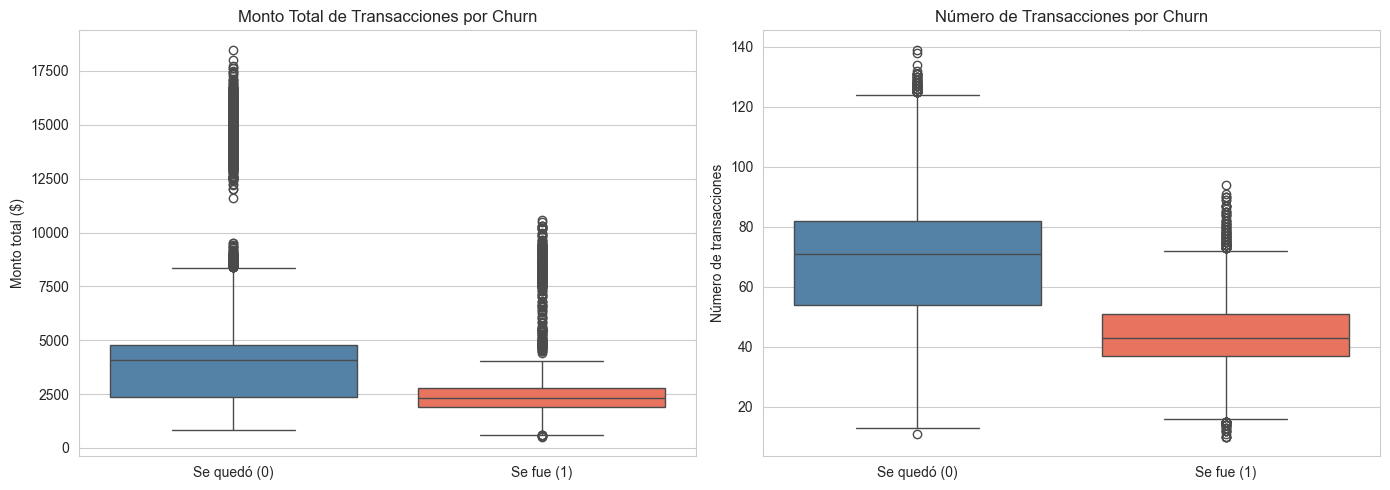

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monto total de transacciones
sns.boxplot(data=df, x='Churn', y='Total_Trans_Amt',
            hue='Churn', palette={0:'steelblue', 1:'tomato'}, 
            legend=False, ax=axes[0])
axes[0].set_title('Monto Total de Transacciones por Churn')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Se quedó (0)', 'Se fue (1)'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Monto total ($)')

# Número de transacciones
sns.boxplot(data=df, x='Churn', y='Total_Trans_Ct',
            hue='Churn', palette={0:'steelblue', 1:'tomato'}, 
            legend=False, ax=axes[1])
axes[1].set_title('Número de Transacciones por Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Se quedó (0)', 'Se fue (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de transacciones')

plt.tight_layout()
plt.show()

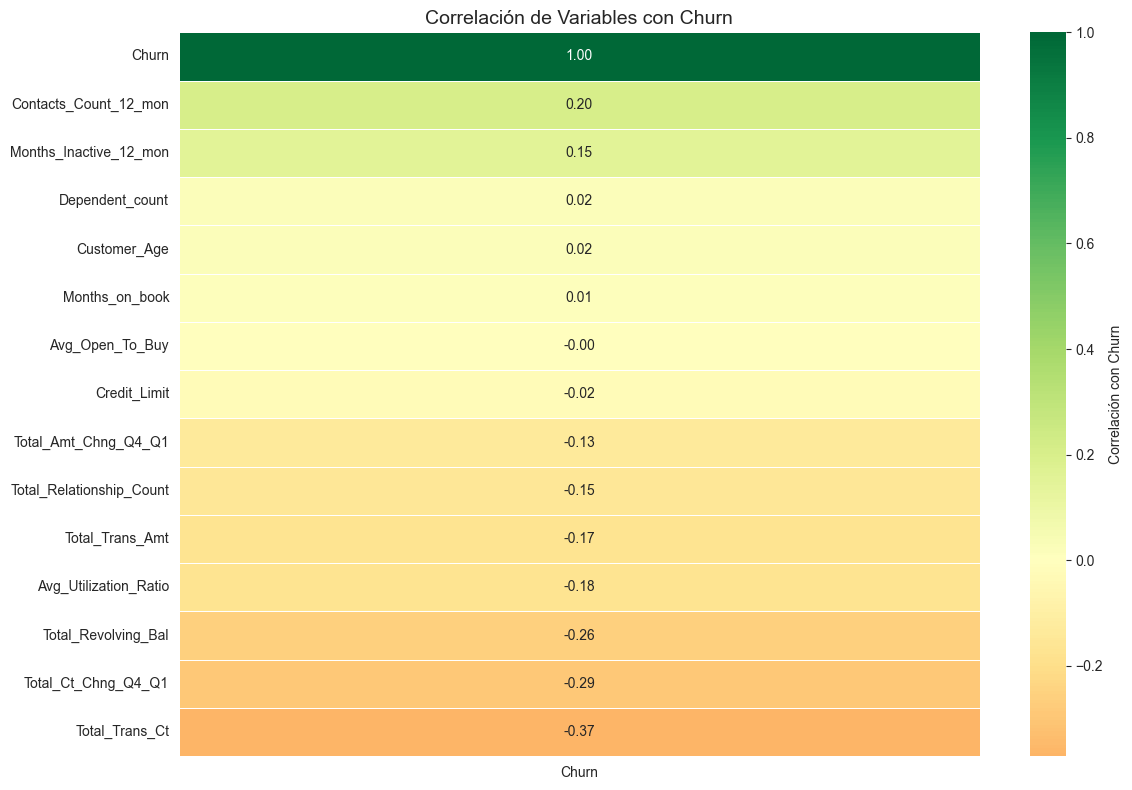

In [11]:
plt.figure(figsize=(12, 8))

# Solo columnas numéricas
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

sns.heatmap(correlation[['Churn']].sort_values('Churn', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlación con Churn'})

plt.title('Correlación de Variables con Churn', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Guardar dataset limpio para usar en el modelo
df.to_csv(r"C:\Users\chris\credit-churn-analysis\data_limpia.csv", index=False)
print("✅ Dataset limpio guardado correctamente")
print(f"   Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

✅ Dataset limpio guardado correctamente
   Filas: 10,127 | Columnas: 21
